In [233]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from dotenv import load_dotenv
from warnings import filterwarnings
filterwarnings("ignore")
load_dotenv()

DATABASE_URL = os.getenv("DATABASE_URL")
engine = create_engine(DATABASE_URL)

pr = lambda x: print(x, end='\n' + '-' * 50 + '\n')

In [235]:
data = pd.read_sql("""
    SELECT * FROM song_ml_view WHERE genre != 'unknown' AND
    song_hotttnesss IS NOT NULL AND
    artist_hotttnesss IS NOT NULL""",
    engine)
df = data.sample(n=min(5000, len(data)), random_state=42)
df.to_csv("../data/sample_5000.csv", index=False)

In [236]:
data = pd.read_csv("../data/sample_5000.csv")
data.head()

,song_id,genre,tempo_bpm,time_signature,key_tonic,key_mode,key_confidence,song_hotttnesss,artist_hotttnesss,unique_chords,total_measures,avg_note_density,chord_entropy,pitch_range,avg_pitch,pitch_variance,avg_note_duration,note_duration_variance,melodic_interval,note_count
0,2906b3ea-a5f8-40d8-9b45-83d8ebba3673,Pop,98.00,4/4,F,major,0.965392,0.417314,0.397852,6,93,5.935484,1.714542,17,69.858696,8.455496,0.466938,0.077058,1.225045,552
1,d84c2df7-c924-4f3d-9ca6-0e194865bedb,Electronic,107.29,4/4,F,major,0.817581,0.697754,0.533117,7,103,5.038835,1.662375,19,33.797688,14.296829,0.486031,0.172222,2.142857,519
2,87530d40-4256-4343-8aa8-6229e18cd79f,Rock,121.00,4/4,F,major,0.910809,0.615280,0.305038,6,72,3.430556,1.437759,15,35.607287,13.808565,1.165992,0.291440,3.845528,247
3,67bf984d-c357-415f-9628-25e0eca2c81f,Pop,124.00,8/8,C#,major,0.896920,0.253840,0.364456,6,106,0.641509,1.673444,12,34.147059,14.664618,1.944853,1.775831,1.925373,68
4,84e97cae-46a0-4770-9911-9f1dd2200162,Rock,88.00,4/4,F,major,0.657337,0.777617,0.683658,4,68,3.352941,1.152361,14,72.504386,7.044034,0.485380,0.213931,2.202643,228


In [237]:
df = data.copy()
df.info(), df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   song_id                 5000 non-null   object 
 1   genre                   5000 non-null   object 
 2   tempo_bpm               5000 non-null   float64
 3   time_signature          5000 non-null   object 
 4   key_tonic               5000 non-null   object 
 5   key_mode                5000 non-null   object 
 6   key_confidence          5000 non-null   float64
 7   song_hotttnesss         5000 non-null   float64
 8   artist_hotttnesss       5000 non-null   float64
 9   unique_chords           5000 non-null   int64  
 10  total_measures          5000 non-null   int64  
 11  avg_note_density        5000 non-null   float64
 12  chord_entropy           5000 non-null   float64
 13  pitch_range             5000 non-null   int64  
 14  avg_pitch               5000 non-null   

(None, (5000, 20))

In [238]:
df.isna().sum()

song_id                   0
genre                     0
tempo_bpm                 0
time_signature            0
key_tonic                 0
key_mode                  0
key_confidence            0
song_hotttnesss           0
artist_hotttnesss         0
unique_chords             0
total_measures            0
avg_note_density          0
chord_entropy             0
pitch_range               0
avg_pitch                 0
pitch_variance            0
avg_note_duration         0
note_duration_variance    0
melodic_interval          0
note_count                0
dtype: int64

In [239]:
df.nunique()

song_id                   5000
genre                       15
tempo_bpm                  367
time_signature              21
key_tonic                   13
key_mode                     2
key_confidence            4376
song_hotttnesss           1892
artist_hotttnesss         1671
unique_chords               13
total_measures             253
avg_note_density          3124
chord_entropy             3030
pitch_range                 86
avg_pitch                 3340
pitch_variance            3497
avg_note_duration         3288
note_duration_variance    3480
melodic_interval          3165
note_count                 652
dtype: int64

In [240]:
df.drop(columns=[col for col in df.columns if df[col].nunique() == len(df)], inplace=True)
df.drop(columns=[col for col in df.columns if df[col].nunique() == 1], inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   genre                   5000 non-null   object 
 1   tempo_bpm               5000 non-null   float64
 2   time_signature          5000 non-null   object 
 3   key_tonic               5000 non-null   object 
 4   key_mode                5000 non-null   object 
 5   key_confidence          5000 non-null   float64
 6   song_hotttnesss         5000 non-null   float64
 7   artist_hotttnesss       5000 non-null   float64
 8   unique_chords           5000 non-null   int64  
 9   total_measures          5000 non-null   int64  
 10  avg_note_density        5000 non-null   float64
 11  chord_entropy           5000 non-null   float64
 12  pitch_range             5000 non-null   int64  
 13  avg_pitch               5000 non-null   float64
 14  pitch_variance          5000 non-null   

In [241]:
df.describe(include=[np.number]).T

,count,mean,std,min,25%,50%,75%,max
tempo_bpm,5000.0,110.483386,33.229487,30.000000,85.000000,110.000000,127.000000,500.000000
key_confidence,5000.0,0.841140,0.080053,0.000000,0.805214,0.855594,0.894839,0.988014
song_hotttnesss,5000.0,0.614004,0.174091,0.192394,0.490808,0.619525,0.742420,1.000000
artist_hotttnesss,5000.0,0.500942,0.110473,0.144685,0.418562,0.492074,0.562158,1.021256
unique_chords,5000.0,4.975400,2.804776,0.000000,3.000000,5.000000,7.000000,12.000000
total_measures,5000.0,102.063600,41.357133,1.000000,76.000000,98.000000,124.000000,318.000000
avg_note_density,5000.0,1.563994,1.905377,0.000000,0.233656,0.686471,2.567778,16.000000
chord_entropy,5000.0,1.201864,0.636394,0.000000,0.858696,1.386294,1.675128,2.396838
pitch_range,5000.0,24.446000,18.105343,0.000000,12.000000,21.000000,36.000000,100.000000
avg_pitch,5000.0,52.867568,22.099295,0.000000,42.142857,60.726753,67.000000,127.000000


# Observations
- Some of the outliers are obviously errors in encoding, for example:
  - note_count of 0
  - avg_pitch of 0
  - pitch_range of 0
- Some are also too extreme to be useful, for example:
  - tempo_bpm > 300
  - pitch_variance > 1000
  - avg_note_density > 20
  - note_count > 1000

In [242]:
# Filter out songs with extreme tempos, zero notes, or zero average pitch or range, which are likely data errors or outliers
df = df[
    (df["tempo_bpm"] <= 300) &
    (df["note_count"] > 0) &
    (df["avg_pitch"] > 0) &
    (df["pitch_range"] > 0) &
    (df["pitch_variance"] < 1000) &
    (df["avg_note_density"] < 20) & 
    (df["note_count"] < 800)
]
df.describe(include=[np.number]).T

,count,mean,std,min,25%,50%,75%,max
tempo_bpm,4226.0,110.123386,32.723296,30.000000,85.000000,110.000000,126.000000,300.000000
key_confidence,4226.0,0.845380,0.074572,0.358594,0.810257,0.857973,0.897199,0.988014
song_hotttnesss,4226.0,0.612884,0.172826,0.198685,0.490904,0.618391,0.741278,1.000000
artist_hotttnesss,4226.0,0.499392,0.108442,0.144685,0.417689,0.490348,0.562710,1.021256
unique_chords,4226.0,5.716990,2.216427,1.000000,4.000000,6.000000,7.000000,12.000000
total_measures,4226.0,102.634406,39.565026,3.000000,77.000000,99.000000,124.000000,318.000000
avg_note_density,4226.0,1.683094,1.744578,0.011765,0.380842,0.904762,2.722046,16.000000
chord_entropy,4226.0,1.392350,0.451305,0.000000,1.158851,1.480953,1.704504,2.396838
pitch_range,4226.0,28.421202,16.494663,1.000000,16.000000,24.000000,41.000000,97.000000
avg_pitch,4226.0,59.569152,12.631245,25.674267,53.539659,62.286535,67.943159,100.768595


# Univariate categorical variables

In [243]:
df.describe(include=[object]).T

,count,unique,top,freq
genre,4226,15,Rock,1598
time_signature,4226,19,4/4,3854
key_tonic,4226,13,C,644
key_mode,4226,2,major,2906


In [244]:
object_cols = df.select_dtypes(include=[object]).columns
for col in object_cols:
    pr(df[col].value_counts())

genre
Rock          1598
Pop           1365
Country        327
Electronic     202
RnB            145
Latin          136
Jazz           107
New Age         78
Metal           73
World           56
Blues           45
Rap             39
Folk            32
Punk            15
Reggae           8
Name: count, dtype: int64
--------------------------------------------------
time_signature
4/4     3854
3/4      124
2/4       71
6/8       46
12/8      34
6/4       23
1/4       19
8/8       18
5/4       10
2/2        8
1/8        4
8/4        4
2/16       3
1/16       2
3/8        2
7/4        1
4/16       1
10/8       1
9/8        1
Name: count, dtype: int64
--------------------------------------------------
key_tonic
C     644
A     554
D     535
G     495
F     448
E     402
B-    262
E-    235
B     210
F#    153
C#    150
A-    114
G#     24
Name: count, dtype: int64
--------------------------------------------------
key_mode
major    2906
minor    1320
Name: count, dtype: int64
-------------

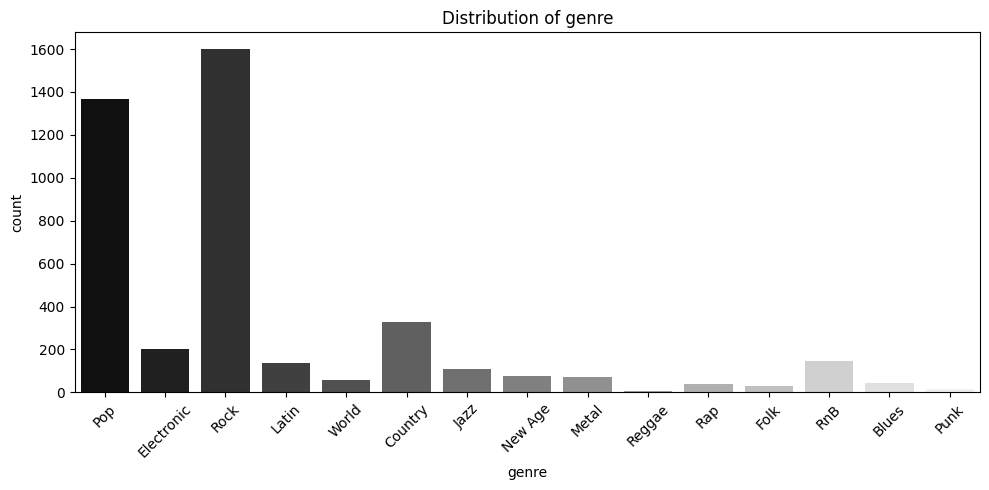

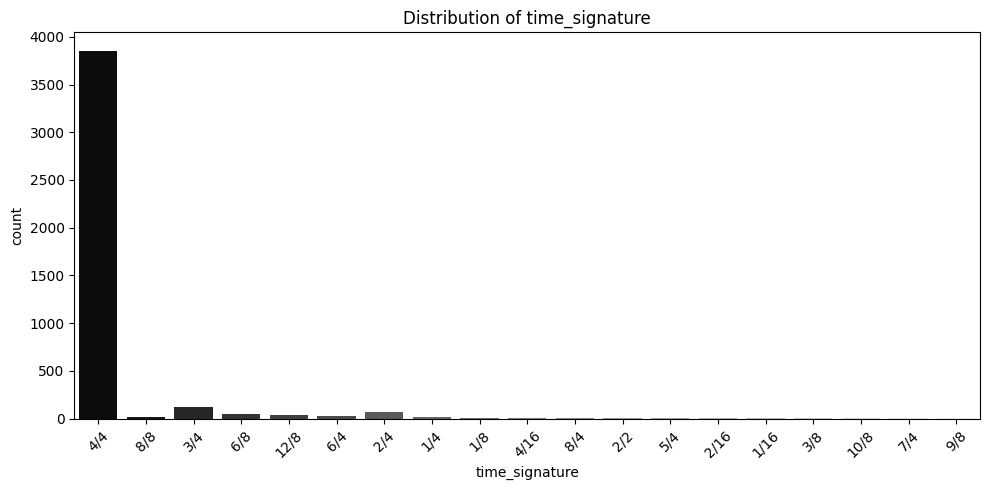

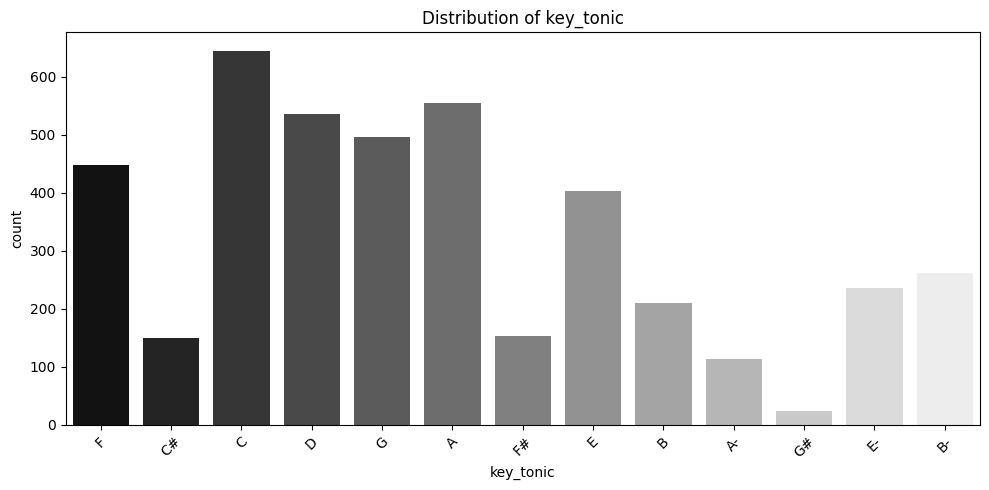

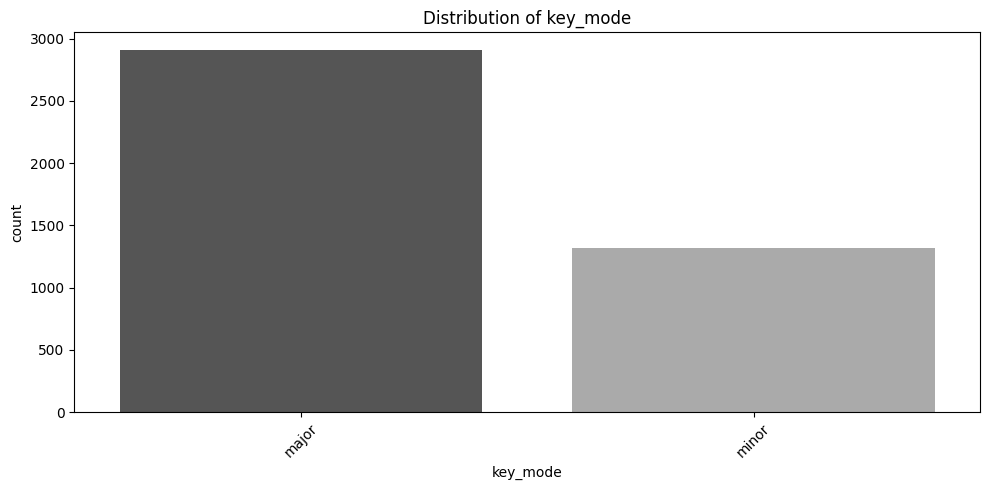

In [245]:
for col in object_cols:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x=col, saturation=0.8, palette="gray")
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Observations

# Univariate continuous variables

In [246]:
# Function to plot a boxplot and a histogram along the same scale
def histogram_boxplot(data, feature, figsize = (12, 7), kde = False, bins = None):

    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12, 7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """

    _, (ax_box2, ax_hist2) = plt.subplots(
        nrows = 2,  # Number of rows of the subplot grid= 2
        sharex = True,  # X-axis will be shared among all subplots
        gridspec_kw = {"height_ratios": (0.25, 0.75)},
        figsize = figsize,
    )  # Creating the 2 subplots
    sns.boxplot(
        data = data, x = feature, ax = ax_box2, showmeans = True, color = "green"
    )  # Boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data = data, x = feature, kde = kde, ax = ax_hist2, bins = bins, palette = "winter"
    ) if bins else sns.histplot(
        data = data, x = feature, kde = kde, ax = ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color = "green", linestyle = "--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color = "black", linestyle = "-"
    )  # Add median to the histogram

    plt.tight_layout()  # Adjust the layout to prevent overlap
    plt.show()  # Show the plot

In [247]:
num_cols = df.select_dtypes(include=np.number).columns
# for col in num_cols:
#     histogram_boxplot(df, col, kde=True)

# Observations
- Right-skewed features (note_count, pitch_variance, note_duration_variance) can be log-transformed

In [248]:
# Transform skewed features with log transformation
pr(df[num_cols].skew().sort_values(ascending=False))

skewed_cols = df[num_cols].skew().abs() > 1 # Threshold for skewness (rule of thumb: >1 is highly skewed)
pr(skewed_cols[skewed_cols].index.tolist())


note_duration_variance    33.354517
avg_note_duration          9.160884
pitch_variance             2.443060
avg_note_density           1.700251
melodic_interval           1.464122
note_count                 1.275600
tempo_bpm                  0.935504
artist_hotttnesss          0.863035
total_measures             0.858824
pitch_range                0.750214
unique_chords              0.060369
song_hotttnesss           -0.098817
avg_pitch                 -0.659713
chord_entropy             -0.913649
key_confidence            -1.400441
dtype: float64
--------------------------------------------------
['key_confidence', 'avg_note_density', 'pitch_variance', 'avg_note_duration', 'note_duration_variance', 'melodic_interval', 'note_count']
--------------------------------------------------


In [ ]:
df_transformed = df.copy()

log_cols = [
    'pitch_variance', 'note_duration_variance',
    'melodic_interval', 'total_measures',
    'avg_note_duration'
]

# df_transformed[log_cols] = np.log1p(df[log_cols])

for col in log_cols:
    pr(f"Applying log transformation to {col} (skewness: {df[col].skew():.2f})")
    df_transformed[f"{col}_log"] = np.log1p(df_transformed[col])
    df_transformed.drop(columns=col, inplace=True)

Applying log transformation to note_count (skewness: 1.28)
--------------------------------------------------
Applying log transformation to pitch_variance (skewness: 2.44)
--------------------------------------------------
Applying log transformation to note_duration_variance (skewness: 33.35)
--------------------------------------------------
Applying log transformation to melodic_interval (skewness: 1.46)
--------------------------------------------------
Applying log transformation to avg_note_density (skewness: 1.70)
--------------------------------------------------
Applying log transformation to total_measures (skewness: 0.86)
--------------------------------------------------
Applying log transformation to avg_note_duration (skewness: 9.16)
--------------------------------------------------


In [250]:
df_transformed.info(), df_transformed.shape

<class 'pandas.core.frame.DataFrame'>
Index: 4226 entries, 0 to 4998
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   genre                       4226 non-null   object 
 1   tempo_bpm                   4226 non-null   float64
 2   time_signature              4226 non-null   object 
 3   key_tonic                   4226 non-null   object 
 4   key_mode                    4226 non-null   object 
 5   key_confidence              4226 non-null   float64
 6   song_hotttnesss             4226 non-null   float64
 7   artist_hotttnesss           4226 non-null   float64
 8   unique_chords               4226 non-null   int64  
 9   chord_entropy               4226 non-null   float64
 10  pitch_range                 4226 non-null   int64  
 11  avg_pitch                   4226 non-null   float64
 12  note_count_log              4226 non-null   float64
 13  pitch_variance_log          4226 non-n

(None, (4226, 19))

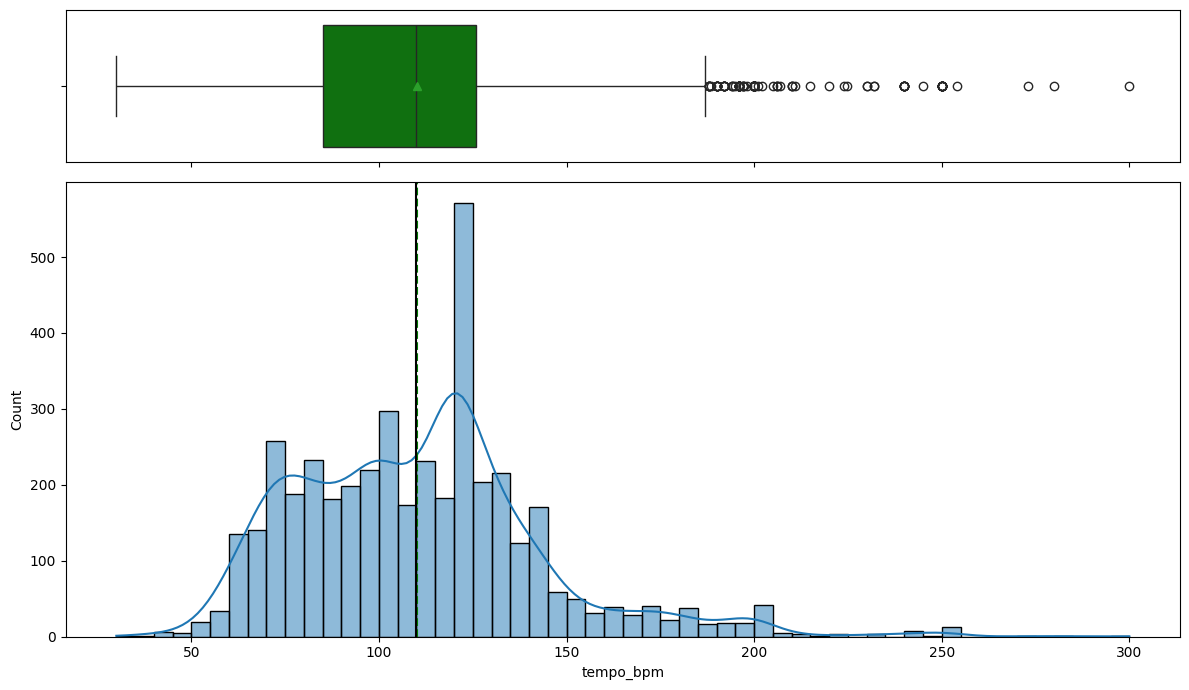

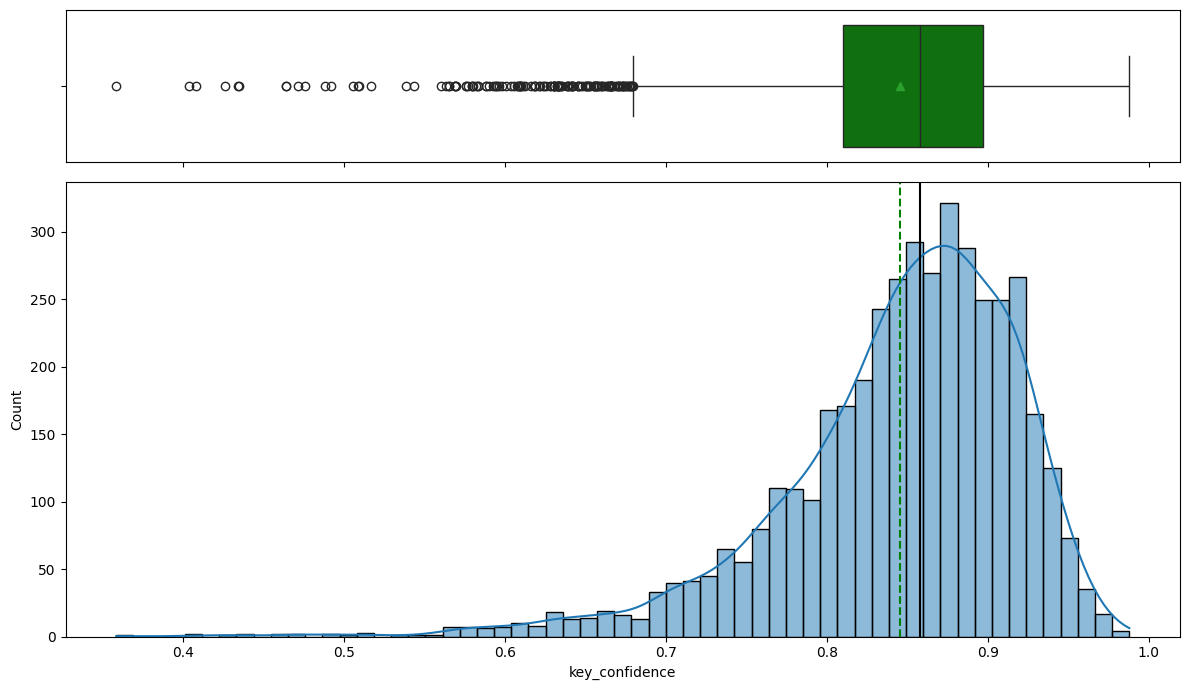

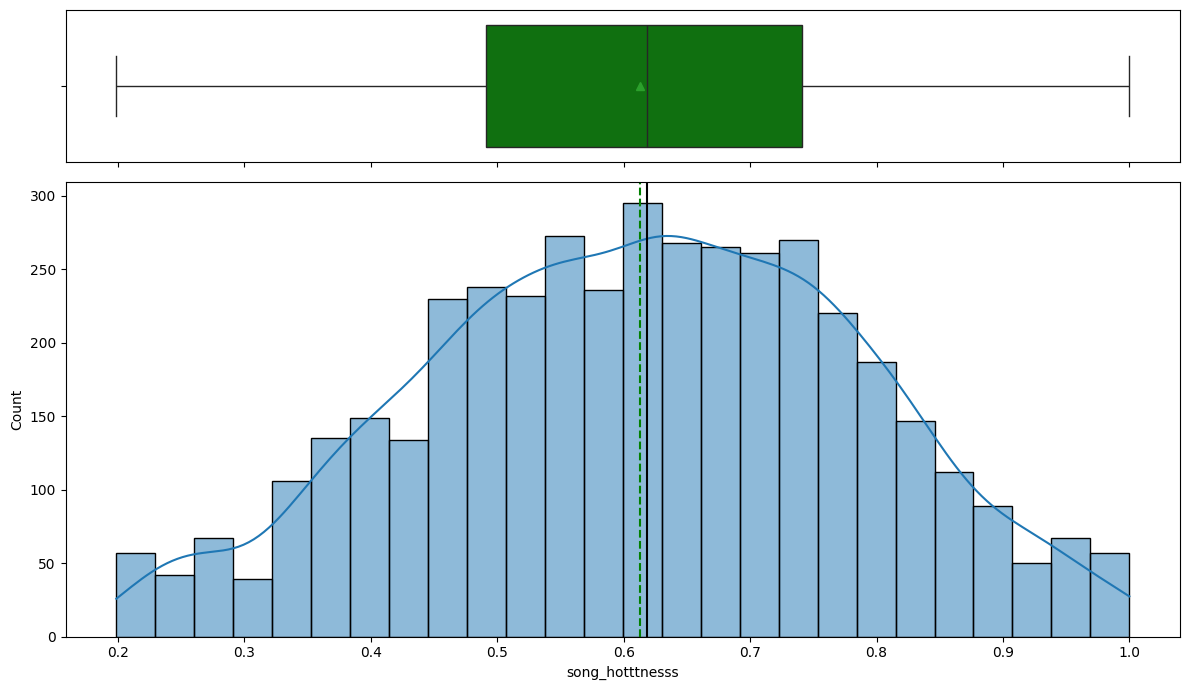

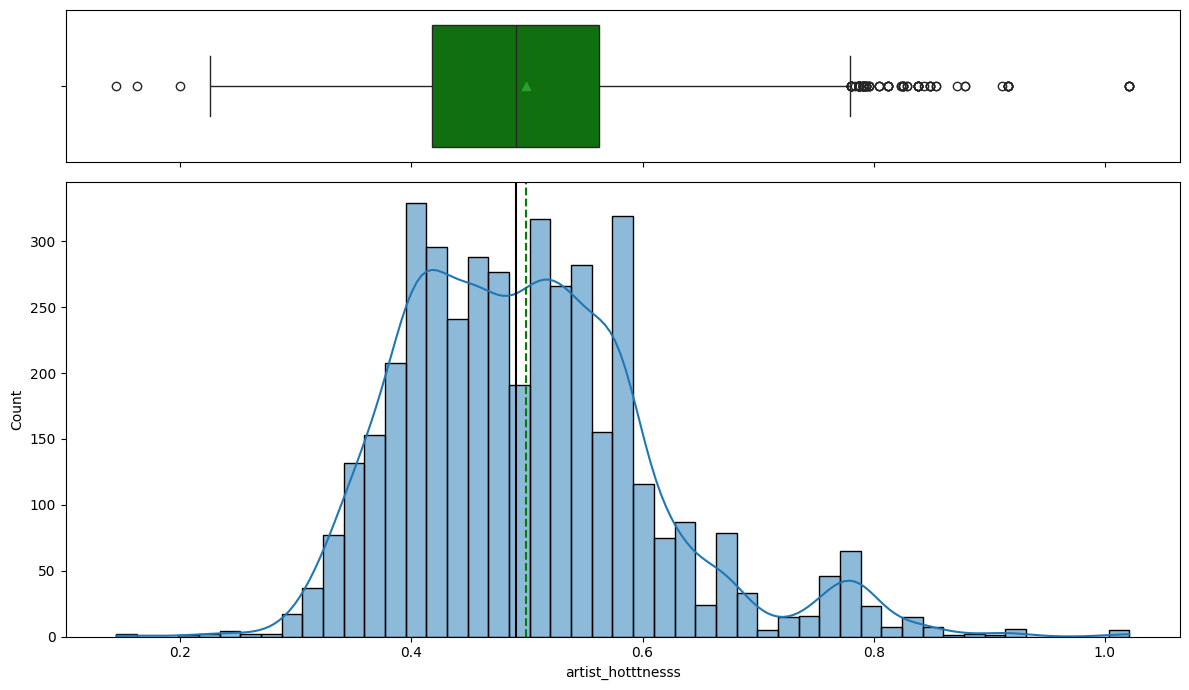

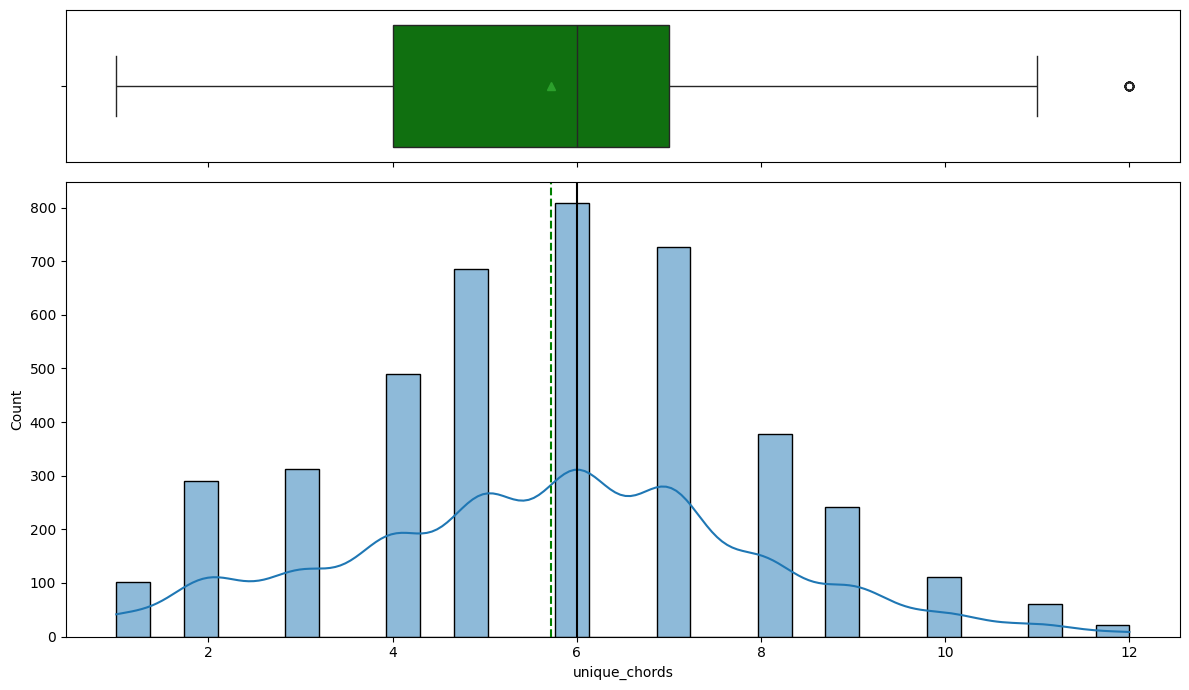

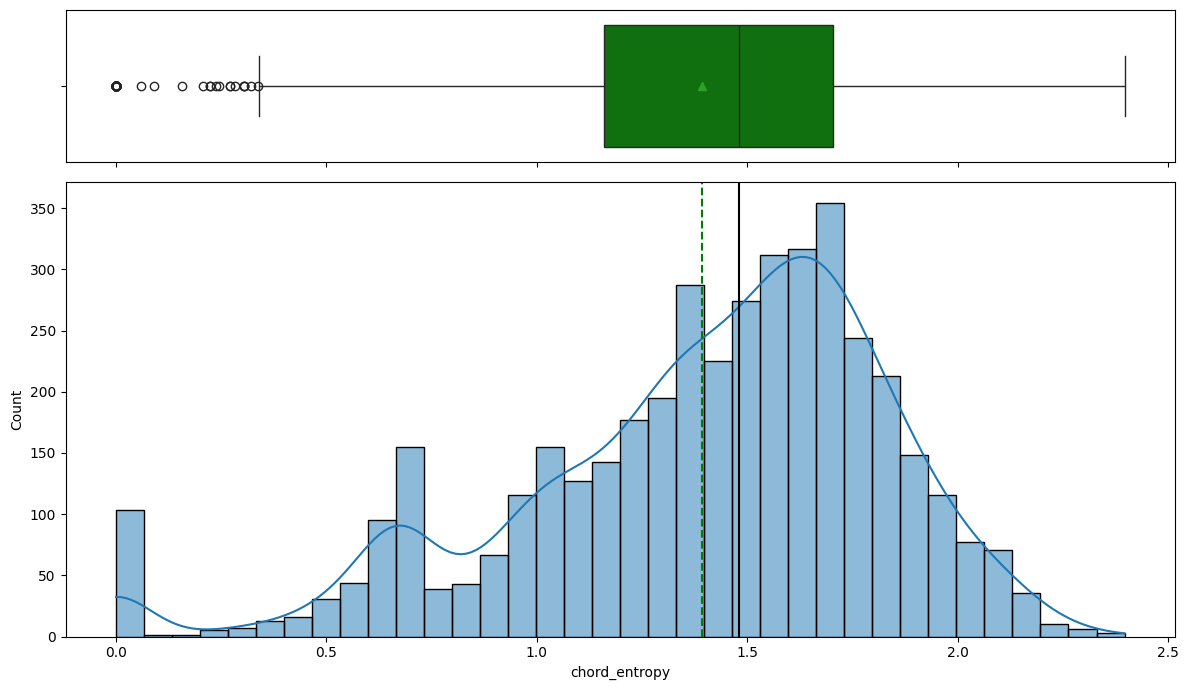

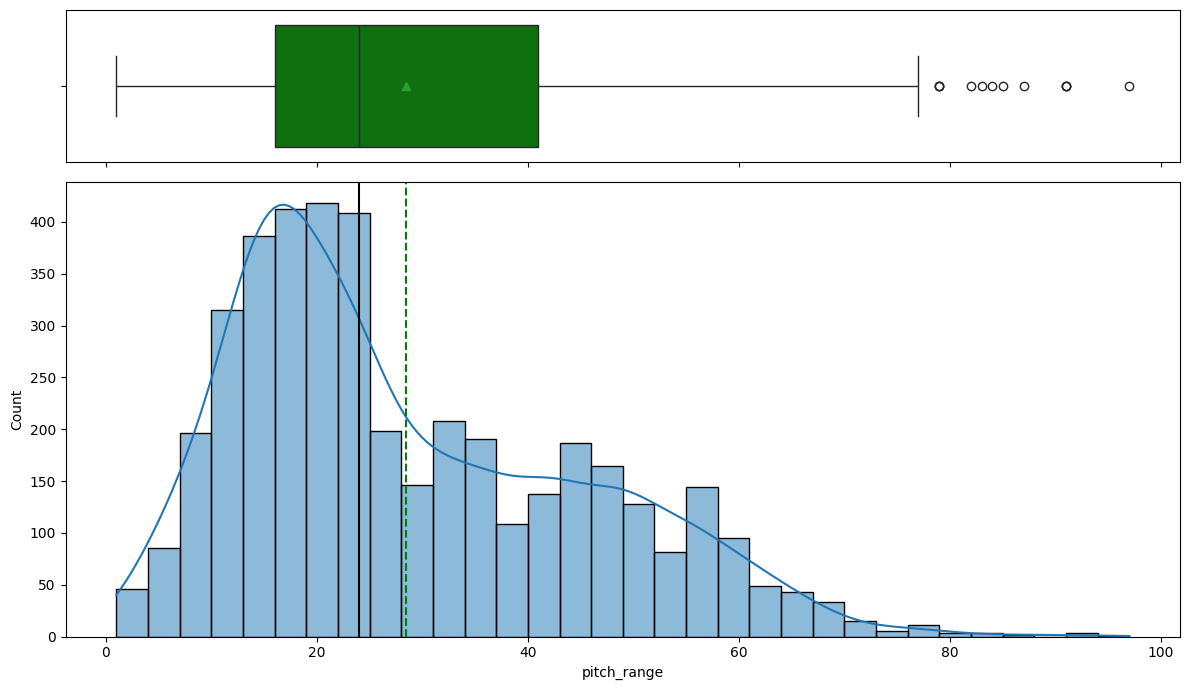

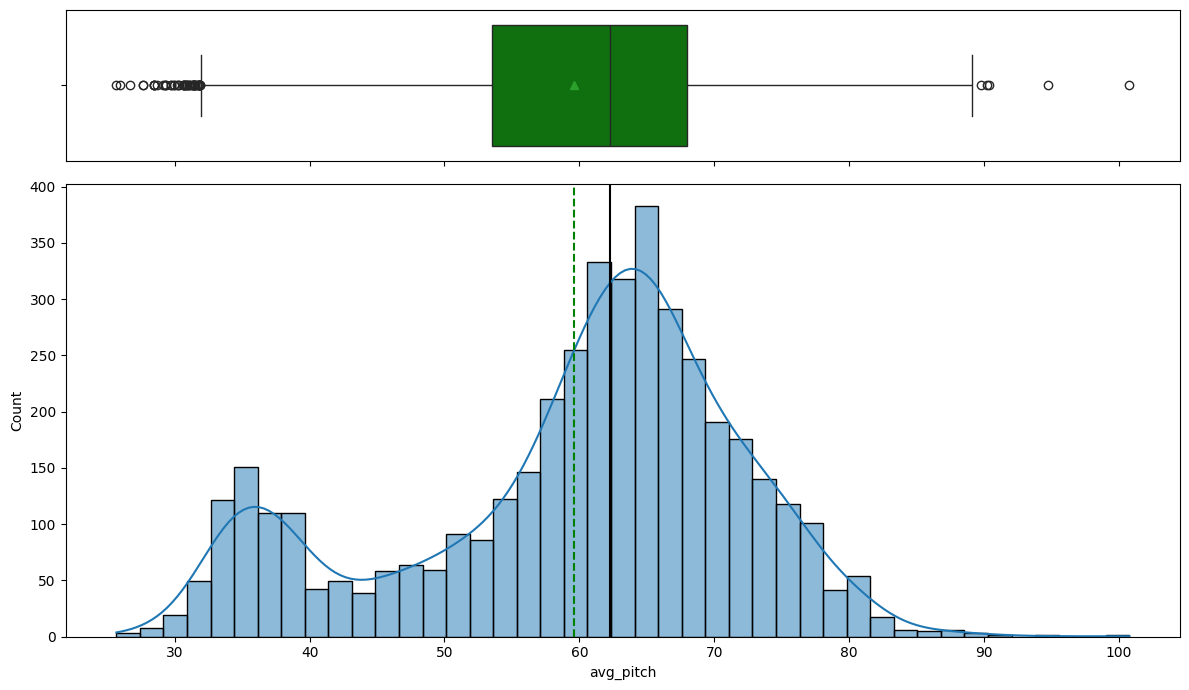

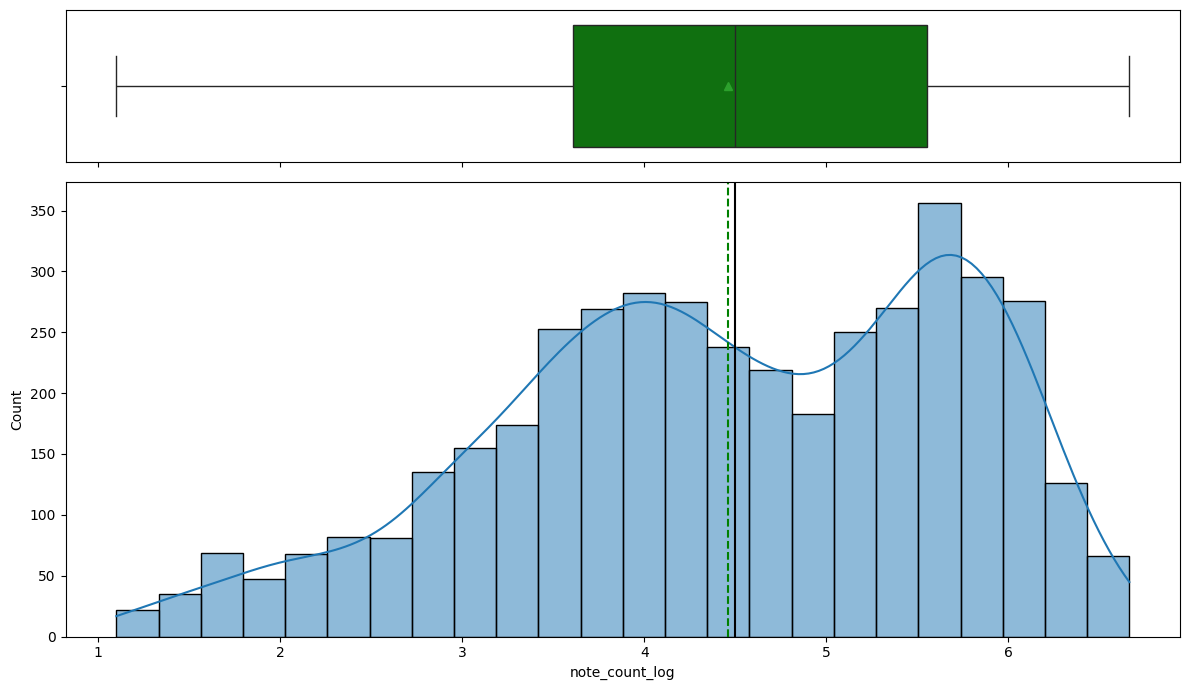

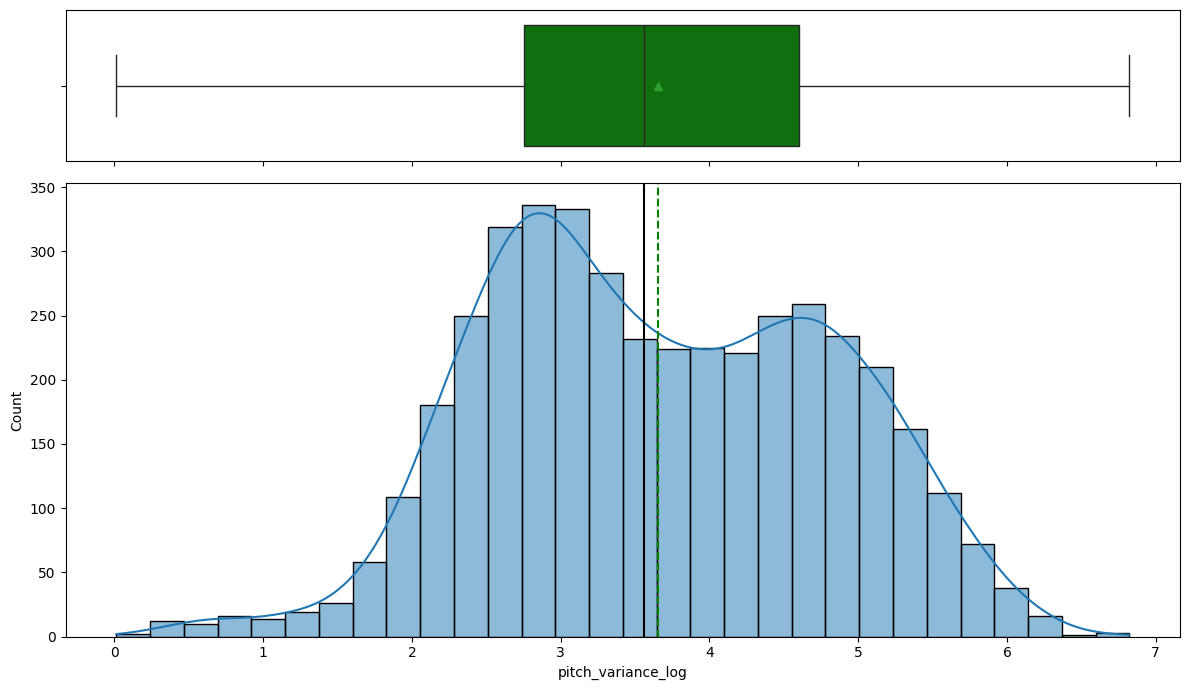

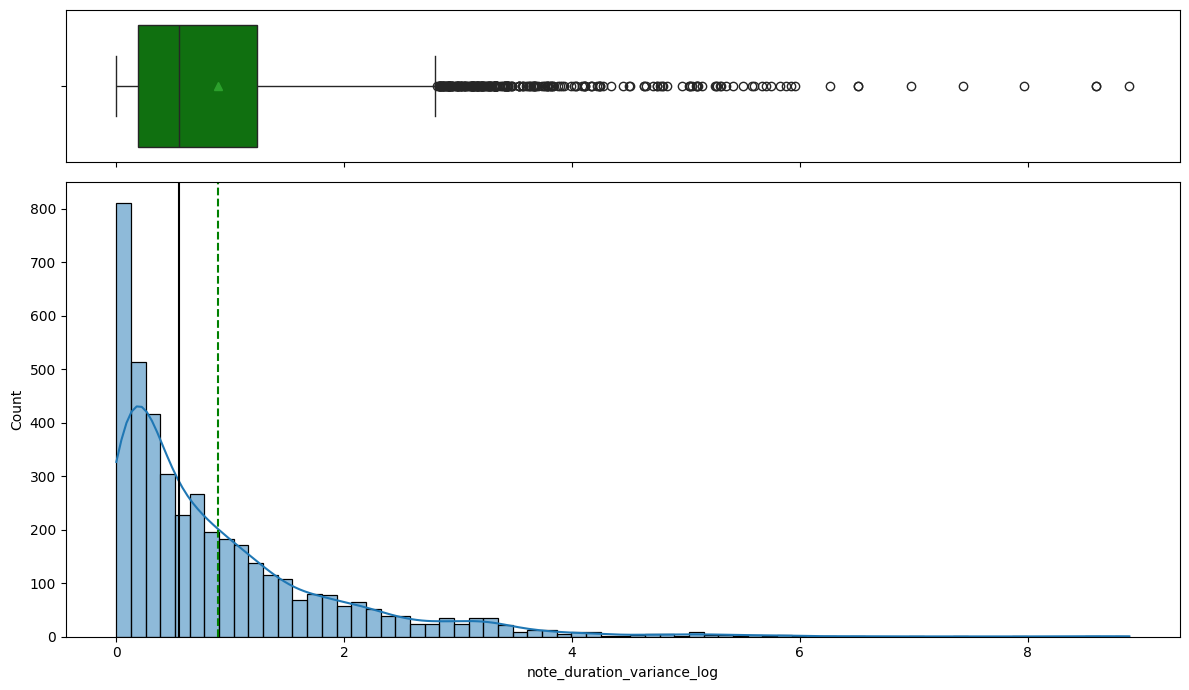

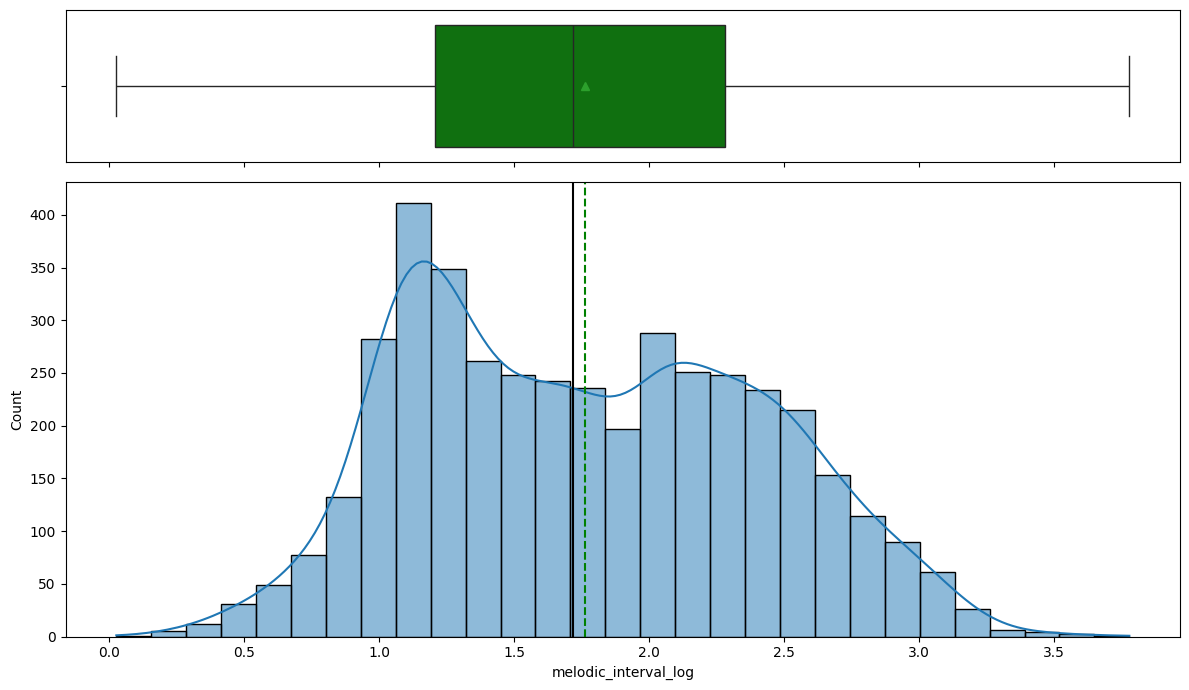

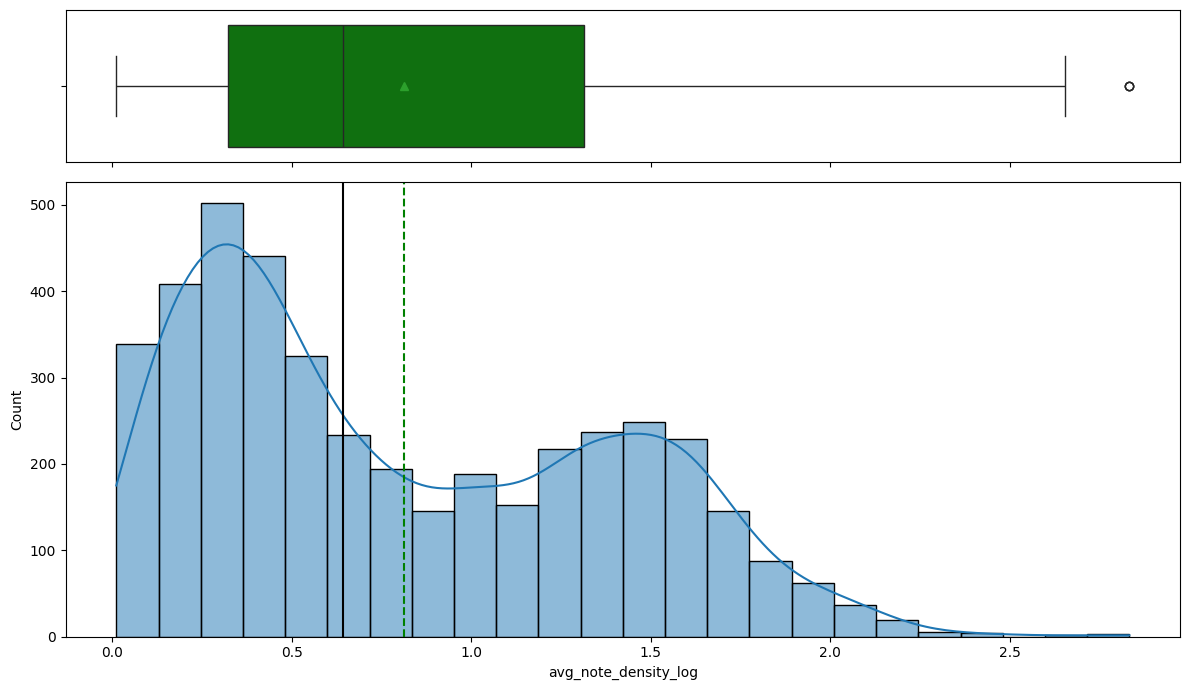

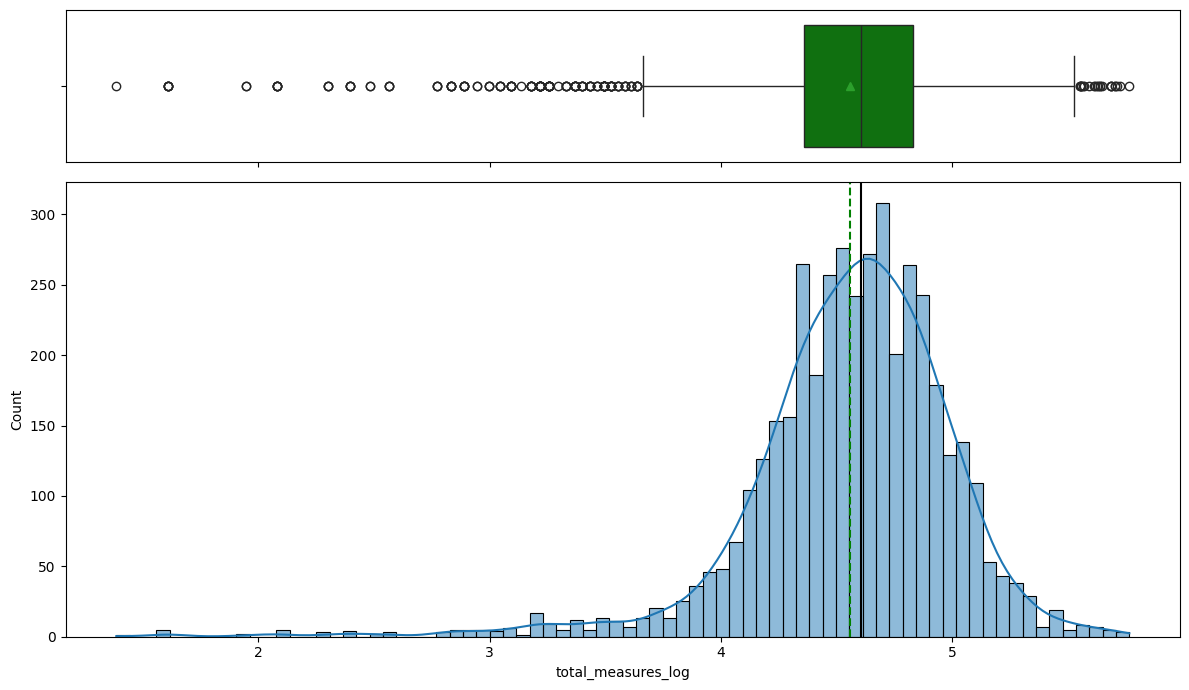

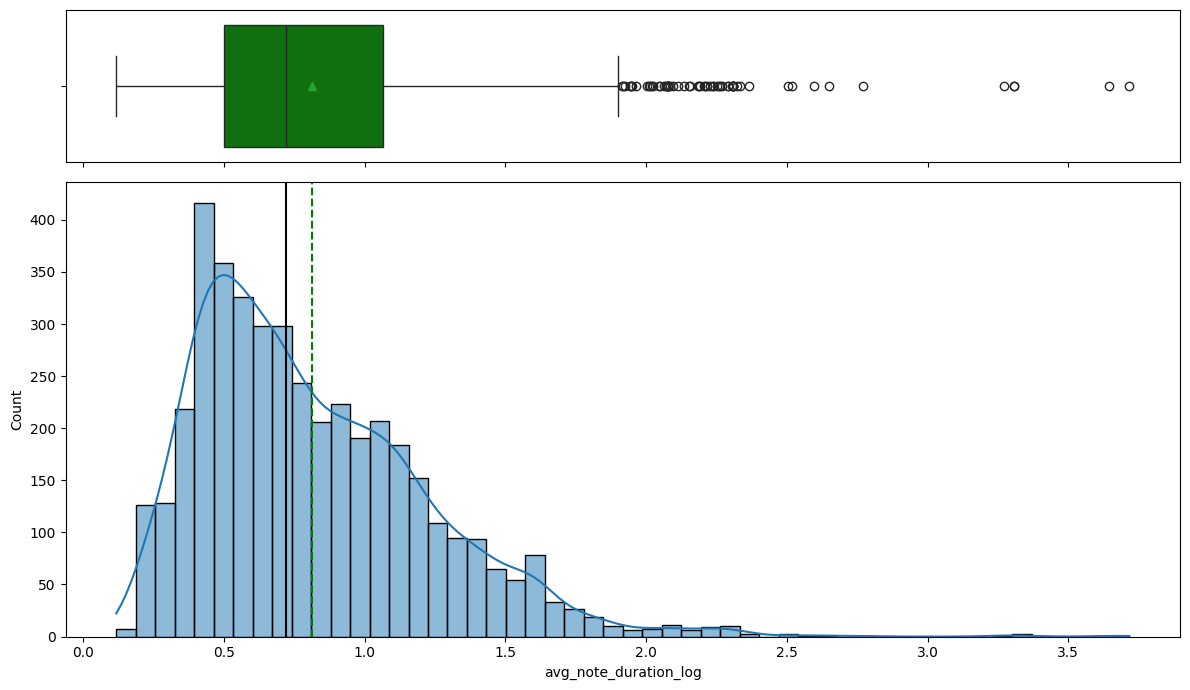

Index(['tempo_bpm', 'key_confidence', 'song_hotttnesss', 'artist_hotttnesss',
       'unique_chords', 'chord_entropy', 'pitch_range', 'avg_pitch',
       'note_count_log', 'pitch_variance_log', 'note_duration_variance_log',
       'melodic_interval_log', 'avg_note_density_log', 'total_measures_log',
       'avg_note_duration_log'],
      dtype='object')

In [251]:
num_cols = df_transformed.select_dtypes(include=np.number).columns
for col in num_cols:
    histogram_boxplot(df_transformed, col, kde=True)

num_cols

# Observations
- tempo_bpm
- key_confidence
- unique_chords
- chord_entropy
- pitch_range
- avg_pitch

- note_count_log
- pitch_variance_log
- note_duration_variance_log
- melodic_interval_log
- avg_note_density_log
- total_measures_log
- avg_note_duration_log


# Multivariate analysis

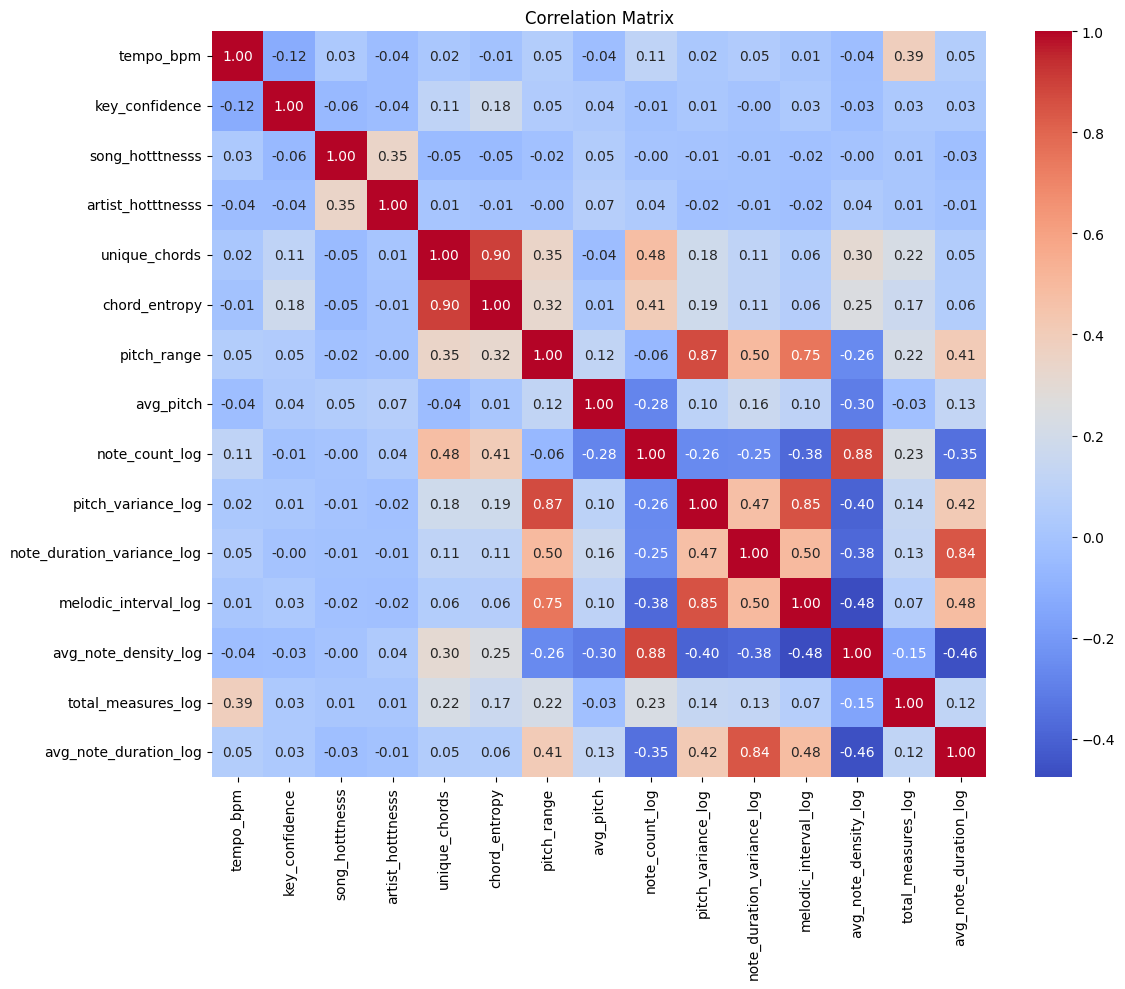

In [252]:
corr = df_transformed.select_dtypes(include=np.number).corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmax=1)
plt.title("Correlation Matrix")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Observations
### Positive correlations
- High correlation between chord_entropy and unique_chords: makes sense as higher chord_entropy indicates more variation from the tonal center.
- High correlation between pitch_variance and pitch_range: higher pitch range should correlate with variance. If a range is consistently over multiple octaves, the variance would also increase.
- High correlation between pitch_range and pitch_variance and melodic_interval: this also aligns with the previous observation, in that pieces which span multiple octaves would also tend to have higher intervals between frets, whereas a piece with a low pitch_range would tend to have smaller jumps.
- High correlation between avg_note_duration and note_duration_variance, which is interesting as this indicates pieces with longer counts are indicative of higher rhythmic complexity.
- Medium correlation between 


### Negative correlations

# Further analysis
- 

In [260]:
def scatter_with_trendline(data, x, y):
    plt.figure(figsize=(10, 6))
    sns.regplot(data=data, x=x, y=y, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
    plt.title(f"{y} vs {x} with Trendline")
    plt.xlabel(x)
    plt.ylabel(y)
    plt.tight_layout()
    plt.show()

def line_with_trendline(data, x, y):
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=data, x=x, y=y)
    plt.title(f"{y} vs {x} with Line")
    plt.xlabel(x)
    plt.ylabel(y)
    plt.tight_layout()
    plt.show()

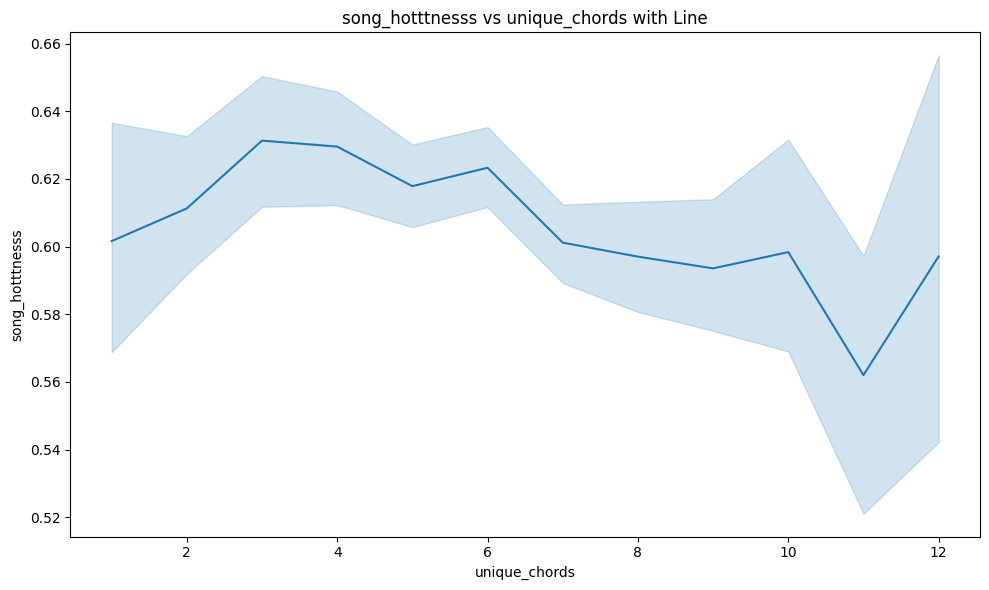

ValueError: Could not interpret value `note_count` for `x`. An entry with this name does not appear in `data`.

<Figure size 1000x600 with 0 Axes>

In [264]:
y = "song_hotttnesss"
line_with_trendline(df_transformed, "unique_chords", y)
line_with_trendline(df_transformed, "note_count", y)
scatter_with_trendline(df_transformed, "chord_entropy", y)
scatter_with_trendline(df_transformed, "pitch_range", y)

y = "tempo_bpm"
line_with_trendline(df_transformed, "unique_chords", y)